# RQ1 - Clones (LLMs, no LLM era, Agentic)

## Loading parquet file for faster access

In [1]:
from pathlib import Path

import pandas as pd

RESULTS_DIR = Path("../results")
PARQUET_FILE = RESULTS_DIR / "clone_detection_results.parquet"

if PARQUET_FILE.exists():
    print(f"Loading existing {PARQUET_FILE.name}...")
    df = pd.read_parquet(PARQUET_FILE)
else:
    raise FileNotFoundError(
        f"Parquet file not found: {PARQUET_FILE}"
    )

print(f"Shape: {df.shape}")
print("\nGeneration types:")
print(df["generation_type"].value_counts())

print("\nLanguages:")
print(df["language"].value_counts())

print("\nFirst rows:")
print(df.head())

Loading existing clone_detection_results.parquet...
Shape: (15678034, 9)

Generation types:
generation_type
no_llm     10469640
llm         2691302
agentic     2517092
Name: count, dtype: int64

Languages:
language
java      13351216
python     2326818
Name: count, dtype: int64

First rows:
                                             pair_id  \
0  892af838-b347-5ffb-872a-67681f9438b1::a9440912...   
1  9c9c45bb-8924-5122-b386-67ae70d8d6a9::a9440912...   
2  a9440912-b527-5594-b678-17c80fb78fef::ee81961d...   
3  525fed8a-e03f-5289-9c21-50a8e2d74673::a9440912...   
4  1064e7f4-372e-526d-bb98-71aa13ddc31b::a9440912...   

                                                file  file_index  \
0  0000_RockyLOMO_rxlib_88b5264ab22d_detailed_res...           0   
1  0000_RockyLOMO_rxlib_88b5264ab22d_detailed_res...           0   
2  0000_RockyLOMO_rxlib_88b5264ab22d_detailed_res...           0   
3  0000_RockyLOMO_rxlib_88b5264ab22d_detailed_res...           0   
4  0000_RockyLOMO_rxlib_88b5264

## Structural Stats

In [2]:
def pair_stats(df, group_columns):
    df = df.drop_duplicates(
        subset=group_columns + ["project", "pair_id"]
    )

    project_pairs = (
        df.groupby(group_columns + ["project"])["pair_id"]
        .nunique()
        .reset_index(name="pairs")
    )

    stats = (
        project_pairs
        .groupby(group_columns)["pairs"]
        .agg(
            projects="count",
            min="min",
            sum="sum",
            max="max",
            mean="mean",
            median="median",
            std="std"
        )
        .reset_index()
    )

    return stats

In [3]:
stats_language_generation = pair_stats(
    df,
    ["language", "generation_type"]
)

print("\nPairs per project by language and generation type:")
print(stats_language_generation.to_string(index=False))


Pairs per project by language and generation type:
language generation_type  projects   min     sum     max          mean  median           std
    java         agentic        25    36 1037248  207071  41489.920000 15261.0  50216.991378
    java             llm        23    45 1026926  257852  44648.956522 29922.0  58485.677500
    java          no_llm        24 11238 4611434 1440471 192143.083333 69935.0 325893.848756
  python         agentic        22     3  221298   80137  10059.000000  4280.5  17924.195217
  python             llm        25    45  318725   56141  12749.000000  5590.0  16045.463811
  python          no_llm        26   153  623386  114616  23976.384615 12863.5  28407.663418


## Compare distributions

In [4]:
df.groupby("generation_type")[["sim", "codebleu"]].mean()

,sim,codebleu
generation_type,,
agentic,0.463998,0.294375
llm,0.421873,0.243402
no_llm,0.46568,0.292521


## Boxplots

In [5]:
from pathlib import Path
import pandas as pd

# Keep only what is needed for the plots
plot_df = df[
    ["language", "generation_type", "sim", "codebleu", "model"]
].copy()

# Convert once
plot_df["sim"] = pd.to_numeric(plot_df["sim"], errors="coerce")
plot_df["codebleu"] = pd.to_numeric(plot_df["codebleu"], errors="coerce")

# Remove rows that cannot be plotted
plot_df = plot_df.dropna(
    subset=["language", "generation_type"]
)

# Optional: enforce a consistent order
plot_df["generation_type"] = pd.Categorical(
    plot_df["generation_type"],
    categories=["no_llm", "llm", "agentic"],
    ordered=True
)

# Save the prepared data
Path("plots").mkdir(exist_ok=True)

plot_df.to_csv(
    "plots/similarity_comparison_data.csv",
    index=False
)

### Semantic/Syntactic similarity

,Language,Metric,Model,Version,N,Mean,Median,Std,Min,Q1,Q3,Max
0,Java,Cosine Similarity,CodeBERT-Cosine Sim.,Pre-LLM,4611434,0.3941,0.3224,0.2994,-0.2202,0.1475,0.6100,1.0000
1,Java,Cosine Similarity,CodeBERT-Cosine Sim.,LLM,1026926,0.3599,0.2806,0.2925,-0.2217,0.1220,0.5616,1.0000
2,Java,Cosine Similarity,CodeBERT-Cosine Sim.,Agentic,1037248,0.3970,0.3205,0.3061,-0.2008,0.1440,0.6210,1.0000
3,Java,Cosine Similarity,CodeT5-Cosine Sim.,Pre-LLM,4611434,0.5403,0.5325,0.2630,-0.2441,0.3324,0.7511,1.0000
4,Java,Cosine Similarity,CodeT5-Cosine Sim.,LLM,1026926,0.4895,0.4712,0.2640,-0.1707,0.2775,0.6964,1.0000
5,Java,Cosine Similarity,CodeT5-Cosine Sim.,Agentic,1037248,0.5183,0.5028,0.2761,-0.1911,0.2962,0.7394,1.0000
6,Java,CodeBLEU*,N/A,Pre-LLM,9222868,0.3001,0.2241,0.2124,0.0000,0.1561,0.3911,1.0000
7,Java,CodeBLEU*,N/A,LLM,2053852,0.2483,0.1877,0.1764,0.0000,0.1416,0.2854,1.0000
8,Java,CodeBLEU*,N/A,Agentic,2074496,0.3013,0.2101,0.2278,0.0000,0.1497,0.4042,1.0000
9,Python,Cosine Similarity,CodeBERT-Cosine Sim.,Pre-LLM,623386,0.4101,0.3255,0.3318,-0.2541,0.1221,0.6910,1.0000


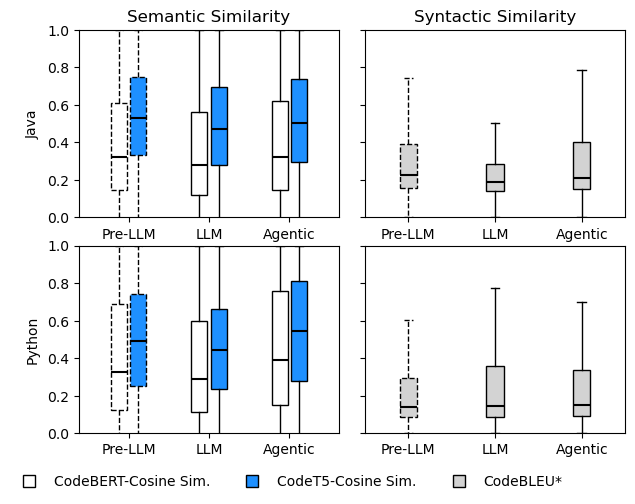

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path


plot_df = pd.read_csv("plots/similarity_comparison_data.csv")
model_names = {
    "microsoft/codebert-base-ft": "CodeBERT-Cosine Sim.",
    "Salesforce/codet5-base-ft": "CodeT5-Cosine Sim."
}

languages = plot_df["language"].unique()
models = plot_df["model"].dropna().unique()

# Consistent order for the three conditions
generation_types = [
    "no_llm",
    "llm",
    "agentic"
]

generation_labels = {
    "no_llm": "Pre-LLM",
    "llm": "LLM",
    "agentic": "Agentic"
}

# Colors for the different models (cosine similarity only)
model_colors = {
    models[0]: "white",
    models[1]: "dodgerblue",
}

# Color for CodeBLEU
codebleu_color = "lightgray"

fig, axes = plt.subplots(
    len(languages),
    2,
    figsize=(7, 2.4 * len(languages)),
    squeeze=False
)

# Textual summary
summary = []
for language in languages:

    lang_df = plot_df[plot_df["language"] == language]

    # Cosine similarity: one entry per model and generation type
    for model in models:

        for generation_type in generation_types:

            values = (
                lang_df.loc[
                    (lang_df["model"] == model) &
                    (lang_df["generation_type"] == generation_type),
                    "sim"
                ]
                .dropna()
            )

            summary.append({
                "Language": language.capitalize(),
                "Metric": "Cosine Similarity",
                "Model": model_names[model],
                "Version": generation_labels[generation_type],
                "N": len(values),
                "Mean": values.mean(),
                "Median": values.median(),
                "Std": values.std(),
                "Min": values.min(),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "Max": values.max()
            })

    
    # CodeBLEU: model-independent, one entry per generation type
    for generation_type in generation_types:

        values = (
            lang_df.loc[
                lang_df["generation_type"] == generation_type,
                "codebleu"
            ]
            .dropna()
        )

        summary.append({
            "Language": language.capitalize(),
            "Metric": "CodeBLEU*",
            "Model": "N/A",
            "Version": generation_labels[generation_type],
            "N": len(values),
            "Mean": values.mean(),
            "Median": values.median(),
            "Std": values.std(),
            "Min": values.min(),
            "Q1": values.quantile(0.25),
            "Q3": values.quantile(0.75),
            "Max": values.max()
        })

summary_df = pd.DataFrame(summary)
display(
    summary_df.style.format({
        "Mean": "{:.4f}",
        "Median": "{:.4f}",
        "Std": "{:.4f}",
        "Min": "{:.4f}",
        "Q1": "{:.4f}",
        "Q3": "{:.4f}",
        "Max": "{:.4f}"
    })
)
# Three groups instead of two
base_positions = {
    "no_llm": 1,
    "llm": 2,
    "agentic": 3
}

# Offsets for the two models in cosine similarity plots
offsets = {
    0: -0.12,
    1:  0.12
}

box_width = 0.20
for row, language in enumerate(languages):

    lang_df = plot_df[plot_df["language"] == language]

    # Cosine Similarity
    ax = axes[row, 0]

    for model_idx, model in enumerate(models):

        for generation_type in generation_types:

            values = (
                lang_df.loc[
                    (lang_df["model"] == model) &
                    (lang_df["generation_type"] == generation_type),
                    "sim"
                ]
                .dropna()
            )

            if values.empty:
                continue

            position = (
                base_positions[generation_type]
                + offsets[model_idx]
            )

            bp = ax.boxplot(
                values,
                positions=[position],
                widths=box_width,
                patch_artist=True,
                showfliers=False
            )

            # Fill color identifies the model
            for patch in bp["boxes"]:
                patch.set_facecolor(model_colors[model])
                patch.set_edgecolor("black")

                # Dashed outline for No LLM
                if generation_type == "no_llm":
                    patch.set_linestyle("--")

            # Whiskers
            for whisker in bp["whiskers"]:
                whisker.set_color("black")

                if generation_type == "no_llm":
                    whisker.set_linestyle("--")

            # Caps
            for cap in bp["caps"]:
                cap.set_color("black")

                if generation_type == "no_llm":
                    cap.set_linestyle("--")

            # Median
            for median in bp["medians"]:
                median.set_color("black")
                median.set_linewidth(1.5)
                median.set_linestyle("-")
    
    # CodeBLEU
    ax = axes[row, 1]

    for generation_type in generation_types:

        values = (
            lang_df.loc[
                lang_df["generation_type"] == generation_type,
                "codebleu"
            ]
            .dropna()
        )

        if values.empty:
            continue

        position = base_positions[generation_type]

        bp = ax.boxplot(
            values,
            positions=[position],
            widths=box_width,
            patch_artist=True,
            showfliers=False
        )

        # CodeBLEU uses a single color
        for patch in bp["boxes"]:
            patch.set_facecolor(codebleu_color)
            patch.set_edgecolor("black")

            # Dashed outline for No LLM
            if generation_type == "no_llm":
                patch.set_linestyle("--")

        # Whiskers
        for whisker in bp["whiskers"]:
            whisker.set_color("black")

            if generation_type == "no_llm":
                whisker.set_linestyle("--")

        # Caps
        for cap in bp["caps"]:
            cap.set_color("black")

            if generation_type == "no_llm":
                cap.set_linestyle("--")

        # Median
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)
            median.set_linestyle("-")
   

    for col in range(2):

        ax = axes[row, col]
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([
            "Pre-LLM",
            "LLM",
            "Agentic"
        ])

        ax.set_ylim(0, 1)

        # Remove y-axis numbers from right plots
        if col == 1:
            ax.set_yticklabels([])


    # Language label
    axes[row, 0].text(
        -0.18,
        0.5,
        language.capitalize(),
        transform=axes[row, 0].transAxes,
        rotation=90,
        va="center",
        ha="center"
    )



# Titles  
axes[0, 0].set_title("Semantic Similarity")
axes[0, 1].set_title("Syntactic Similarity")

# Legend 
legend_handles = []

# Model legend entries for cosine similarity
for model in models:

    handle = plt.Line2D(
        [0],
        [0],
        color="black",
        marker="s",
        markersize=9,
        markerfacecolor=model_colors[model],
        markeredgecolor="black",
        linestyle="None",
        label=model_names[model]
    )

    legend_handles.append(handle)

# CodeBLEU legend entry
codebleu_handle = plt.Line2D(
    [0],
    [0],
    color="black",
    marker="s",
    markersize=9,
    markerfacecolor=codebleu_color,
    markeredgecolor="black",
    linestyle="None",
    label="CodeBLEU*"
)

legend_handles.append(codebleu_handle)


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(legend_handles),
    frameon=False
)

# Layout and save 
plt.subplots_adjust(
    wspace=0.10,
    hspace=0.15,
    left=0.2,
    right=0.98,
    bottom=0.08,
    top=0.92
)

Path("plots").mkdir(exist_ok=True)
plt.savefig(
    "plots/similarity_comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

## Statistical Tests

### Semantic Sim

In [7]:
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# df = your dataframe

df_sem = df.copy()

df_sem["sim"] = pd.to_numeric(
    df_sem["sim"],
    errors="coerce"
)

df_sem = df_sem.dropna(
    subset=[
        "sim",
        "generation_type",
        "project",
        "language",
        "model"
    ]
)

df_sem["generation_type"] = pd.Categorical(
    df_sem["generation_type"],
    categories=[
        "no_llm",
        "llm",
        "agentic"
    ],
    ordered=True
)

semantic_results = []

for model in df_sem["model"].unique():

    for language in df_sem["language"].unique():

        data = df_sem[
            (df_sem["model"] == model) &
            (df_sem["language"] == language)
        ].copy()

        # One median similarity per project and era
        project_data = (
            data
            .groupby(
                ["project", "generation_type"],
                observed=True
            )["sim"]
            .median()
            .reset_index()
        )

        # Put the three eras into columns
        wide = (
            project_data
            .pivot(
                index="project",
                columns="generation_type",
                values="sim"
            )
            .dropna(
                subset=[
                    "no_llm",
                    "llm",
                    "agentic"
                ]
            )
        )

        n_projects = len(wide)

        if n_projects < 3:
            continue

        # Pairwise Wilcoxon signed-rank tests
        comparisons = [
            ("llm_vs_no_llm", "llm", "no_llm"),
            ("agentic_vs_no_llm", "agentic", "no_llm"),
            ("agentic_vs_llm", "agentic", "llm")
        ]

        for comparison, treatment, baseline in comparisons:

            x = wide[treatment]
            y = wide[baseline]

            statistic, p_value = wilcoxon(
                x,
                y,
                alternative="two-sided",
                zero_method="wilcox",
                method="auto"
            )

            # Project-level paired differences
            differences = x - y

            nonzero = differences[
                differences != 0
            ]

            if len(nonzero) > 0:

                abs_diff = nonzero.abs()

                ranks = abs_diff.rank(
                    method="average"
                )

                positive_rank_sum = ranks[
                    nonzero > 0
                ].sum()

                negative_rank_sum = ranks[
                    nonzero < 0
                ].sum()

                rank_biserial = (
                    positive_rank_sum -
                    negative_rank_sum
                ) / (
                    positive_rank_sum +
                    negative_rank_sum
                )

            else:
                rank_biserial = 0.0

            median_difference = (
                x - y
            ).median()

            semantic_results.append({
                "model": model,
                "language": language,
                "comparison": comparison,
                "n_projects": n_projects,
                "statistic": statistic,
                "p_value": p_value,
                "effect_size": rank_biserial,
                "effect_size_name": "rank_biserial",
                "median_difference": median_difference
            })


semantic_results = pd.DataFrame(
    semantic_results
)

# Benjamini-Hochberg correction
semantic_results["p_adjusted"] = multipletests(
    semantic_results["p_value"],
    method="fdr_bh"
)[1]

semantic_results["significant"] = (
    semantic_results["p_adjusted"] < 0.05
)

semantic_results

,model,language,comparison,n_projects,statistic,p_value,effect_size,effect_size_name,median_difference,p_adjusted,significant
0,microsoft/codebert-base-ft,java,llm_vs_no_llm,23,85.0,0.111426,-0.384058,rank_biserial,-0.041090,0.179013,False
1,microsoft/codebert-base-ft,java,agentic_vs_no_llm,23,80.0,0.080203,-0.420290,rank_biserial,-0.024021,0.164391,False
2,microsoft/codebert-base-ft,java,agentic_vs_llm,23,117.0,0.539919,0.152174,rank_biserial,0.006334,0.719892,False
3,microsoft/codebert-base-ft,python,llm_vs_no_llm,21,61.0,0.059507,-0.471861,rank_biserial,-0.039733,0.164391,False
4,microsoft/codebert-base-ft,python,agentic_vs_no_llm,21,107.0,0.785365,0.073593,rank_biserial,0.036121,0.856762,False
5,microsoft/codebert-base-ft,python,agentic_vs_llm,21,64.0,0.075980,0.445887,rank_biserial,0.065994,0.164391,False
6,Salesforce/codet5-base-ft,java,llm_vs_no_llm,23,42.0,0.002416,-0.695652,rank_biserial,-0.055151,0.014494,True
7,Salesforce/codet5-base-ft,java,agentic_vs_no_llm,23,38.0,0.001458,-0.724638,rank_biserial,-0.051812,0.014494,True
8,Salesforce/codet5-base-ft,java,agentic_vs_llm,23,136.0,0.964313,-0.014493,rank_biserial,-0.002393,0.964313,False
9,Salesforce/codet5-base-ft,python,llm_vs_no_llm,21,65.0,0.082195,-0.437229,rank_biserial,-0.042503,0.164391,False


### Syntactic Sim

In [8]:
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# df = your dataframe

df_syn = df.copy()

df_syn["codebleu"] = pd.to_numeric(
    df_syn["codebleu"],
    errors="coerce"
)

df_syn = df_syn.dropna(
    subset=[
        "codebleu",
        "generation_type",
        "project",
        "language"
    ]
)

df_syn["generation_type"] = pd.Categorical(
    df_syn["generation_type"],
    categories=[
        "no_llm",
        "llm",
        "agentic"
    ],
    ordered=True
)

syntactic_results = []

for language in df_syn["language"].unique():

    data = df_syn[
        df_syn["language"] == language
    ].copy()

    # One median CodeBLEU per project and era
    project_data = (
        data
        .groupby(
            ["project", "generation_type"],
            observed=True
        )["codebleu"]
        .median()
        .reset_index()
    )

    # Put the three eras into columns
    wide = (
        project_data
        .pivot(
            index="project",
            columns="generation_type",
            values="codebleu"
        )
        .dropna(
            subset=[
                "no_llm",
                "llm",
                "agentic"
            ]
        )
    )

    n_projects = len(wide)

    if n_projects < 3:
        continue

    comparisons = [
        ("llm_vs_no_llm", "llm", "no_llm"),
        ("agentic_vs_no_llm", "agentic", "no_llm"),
        ("agentic_vs_llm", "agentic", "llm")
    ]

    for comparison, treatment, baseline in comparisons:

        x = wide[treatment]
        y = wide[baseline]

        statistic, p_value = wilcoxon(
            x,
            y,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto"
        )

        # Project-level paired differences
        differences = x - y

        nonzero = differences[
            differences != 0
        ]

        if len(nonzero) > 0:

            abs_diff = nonzero.abs()

            ranks = abs_diff.rank(
                method="average"
            )

            positive_rank_sum = ranks[
                nonzero > 0
            ].sum()

            negative_rank_sum = ranks[
                nonzero < 0
            ].sum()

            rank_biserial = (
                positive_rank_sum -
                negative_rank_sum
            ) / (
                positive_rank_sum +
                negative_rank_sum
            )

        else:
            rank_biserial = 0.0

        median_difference = (
            x - y
        ).median()

        syntactic_results.append({
            "language": language,
            "comparison": comparison,
            "n_projects": n_projects,
            "statistic": statistic,
            "p_value": p_value,
            "effect_size": rank_biserial,
            "effect_size_name": "rank_biserial",
            "median_difference": median_difference
        })


syntactic_results = pd.DataFrame(
    syntactic_results
)

# Benjamini-Hochberg correction
# 6 tests: 3 comparisons × 2 languages

syntactic_results["p_adjusted"] = multipletests(
    syntactic_results["p_value"],
    method="fdr_bh"
)[1]

syntactic_results["significant"] = (
    syntactic_results["p_adjusted"] < 0.05
)

syntactic_results

,language,comparison,n_projects,statistic,p_value,effect_size,effect_size_name,median_difference,p_adjusted,significant
0,java,llm_vs_no_llm,23,43.0,0.002726,-0.688406,rank_biserial,-0.043748,0.008179,True
1,java,agentic_vs_no_llm,23,25.0,0.000215,-0.818841,rank_biserial,-0.039737,0.001289,True
2,java,agentic_vs_llm,23,123.0,0.664999,-0.108696,rank_biserial,-0.004121,0.797999,False
3,python,llm_vs_no_llm,21,57.0,0.042080,-0.506494,rank_biserial,-0.019263,0.063120,False
4,python,agentic_vs_no_llm,21,112.0,0.918694,0.030303,rank_biserial,-0.000622,0.918694,False
5,python,agentic_vs_llm,21,57.0,0.042080,0.506494,rank_biserial,0.018641,0.063120,False


In [10]:
import pandas as pd

FILE = "../results/function_filtering_comparison.csv"

df = pd.read_csv(FILE)

print("Shape:", df.shape)
print()

print("Descriptive statistics:")
print(
    df[
        [
            "functions_before",
            "functions_after",
            "functions_removed",
            "removed_percentage",
        ]
    ].describe()
)

print()
print("Total functions:")
print(f"Before filtering: {df['functions_before'].sum():,}")
print(f"After filtering:  {df['functions_after'].sum():,}")
print(f"Removed:          {df['functions_removed'].sum():,}")

total_before = df["functions_before"].sum()
total_removed = df["functions_removed"].sum()

print(
    f"Overall removed:  "
    f"{100 * total_removed / total_before:.2f}%"
)

print()
print("Removal percentage:")
print(
    df["removed_percentage"]
    .describe()
)

print()
print("Projects with highest removal:")
print(
    df[
        [
            "file",
            "functions_before",
            "functions_after",
            "functions_removed",
            "removed_percentage",
        ]
    ]
    .sort_values("removed_percentage", ascending=False)
    .head(20)
    .to_string(index=False)
)

Shape: (97, 5)

Descriptive statistics:
       functions_before  functions_after  functions_removed  \
count         97.000000        97.000000          97.000000   
mean       10974.711340      1920.154639        9054.556701   
std        20033.533525      2983.187265       18080.096374   
min          135.000000         1.000000          80.000000   
25%         1283.000000       111.000000         960.000000   
50%         3811.000000       560.000000        2859.000000   
75%        11779.000000      2656.000000        8334.000000   
max       119591.000000     17624.000000      112132.000000   

       removed_percentage  
count           97.000000  
mean            77.772848  
std             20.254404  
min             11.940299  
25%             71.940299  
50%             82.636085  
75%             93.410123  
max             99.980754  

Total functions:
Before filtering: 1,064,547
After filtering:  186,255
Removed:          878,292
Overall removed:  82.50%

Removal percenta